In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
rdt = pd.read_csv("Retail_Data_Transactions.csv")
rdt.head()

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78


In [3]:
rdr = pd.read_csv("Retail_Data_Response.csv")
rdr.head()

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1


In [4]:
rdt.dtypes

customer_id      str
trans_date       str
tran_amount    int64
dtype: object

In [5]:
df = rdt.merge(rdr , on="customer_id",how="left")
df.head()

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0


In [6]:
# df.isnull().sum()
df = df.dropna()
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [7]:
df["trans_date"] = pd.to_datetime(df["trans_date"])
df["response"] = df["response"].astype('int64')
df['trans_date'].max()

C:\Users\shree\AppData\Local\Temp\ipykernel_9400\1510530859.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["trans_date"] = pd.to_datetime(df["trans_date"])


Timestamp('2015-03-16 00:00:00')

In [8]:
# CHECK FOR OULINERS #ZSCORE
from scipy import stats
import numpy as np

#claculate zscore
z_scores = np.abs(stats.zscore(df['response']))

# set a threashold 
threshold = 3
outlier = z_scores > threshold

print(df[outlier])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [9]:
# CHECK FOR OULINERS #ZSCORE
from scipy import stats
import numpy as np

#claculate zscore
z_scores = np.abs(stats.zscore(df['tran_amount']))

# set a threashold 
threshold = 3
outlier = z_scores > threshold

print(df[outlier])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


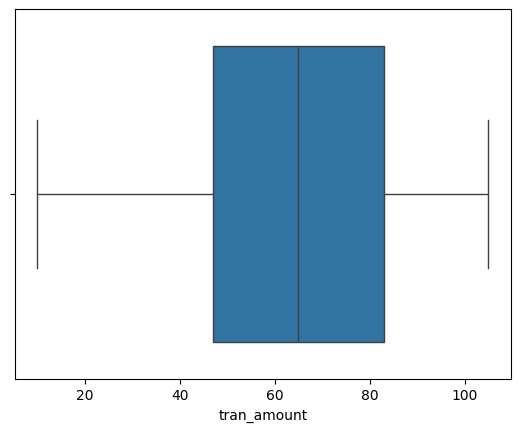

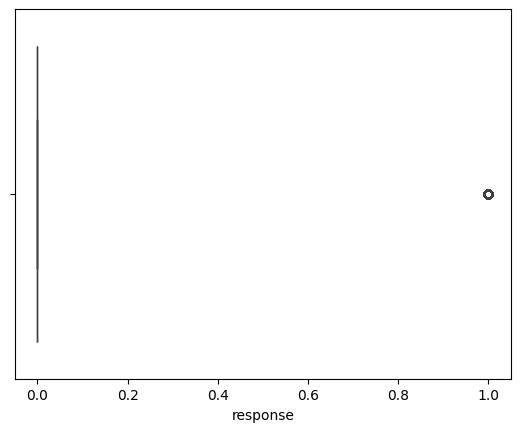

In [10]:
sns.boxplot(x=df['tran_amount'])
plt.show()
sns.boxplot(x=df['response'])
plt.show()

In [11]:
df['tran_amount'].describe()

count    124969.000000
mean         64.995143
std          22.860059
min          10.000000
25%          47.000000
50%          65.000000
75%          83.000000
max         105.000000
Name: tran_amount, dtype: float64

In [12]:
# extracting month fron transaction date and store to new column
df['month'] = df['trans_date'].dt.month
df

,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1,2
1,CS4768,2015-03-15,39,1,3
2,CS2122,2013-02-26,52,0,2
3,CS1217,2011-11-16,99,0,11
4,CS1850,2013-11-20,78,0,11
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6
124996,CS7232,2014-08-19,38,0,8
124997,CS8731,2014-11-28,42,0,11
124998,CS8133,2013-12-14,13,0,12


TOP 3 MONTHS WITH HIGHEST SALES

In [13]:
top_months = df.groupby('month')['tran_amount'].sum()
top_months = top_months.sort_values(ascending=False).reset_index()
top_months.head(3)

,month,tran_amount
0,8,726775
1,10,725058
2,1,724089


FINDING TOP 5 CUSTOMER WITH HIGHEST NUM OF ORDERS

In [14]:
top_cust = df.groupby(by = ('customer_id'))['tran_amount'].count()
top_cust = top_cust.sort_values(ascending=False).reset_index()
top_cust.columns=['ID','num_of_orders']
top_cust.head(5)

,ID,num_of_orders
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS2620,35
4,CS5109,35


In [15]:
# second method 
cust_counts = df['customer_id'].value_counts().reset_index()
cust_counts
top_5_cust = cust_counts.sort_values(by='count',ascending=False).head()
top_5_cust

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS5109,35
4,CS3013,35


BAR CHART 

<function matplotlib.pyplot.show(close=None, block=None)>

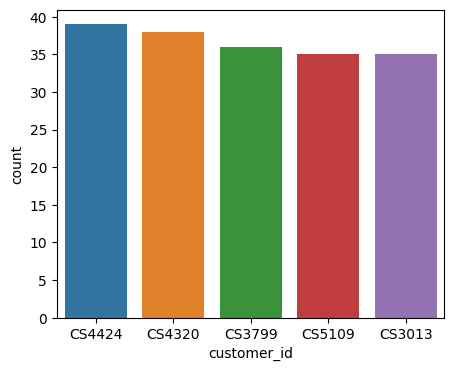

In [16]:
plt.figure(figsize=(5,4))
sns.barplot(x='customer_id',y='count',data=top_5_cust,hue='customer_id')
plt.show

CUSTOMER WITH HIGHEST TOTAL OF TRANSACTION AMOUNT

In [17]:
top_cust_amount = df.groupby('customer_id')['tran_amount'].sum()
top_cust_amount= top_cust_amount.sort_values(ascending=False).reset_index().head()
top_cust_amount

,customer_id,tran_amount
0,CS4424,2933
1,CS4320,2647
2,CS5752,2612
3,CS4660,2527
4,CS3799,2513


BAR CHART TOP CUSTOMER WITH TOTAL TRANSACTION AMOUNT

<function matplotlib.pyplot.show(close=None, block=None)>

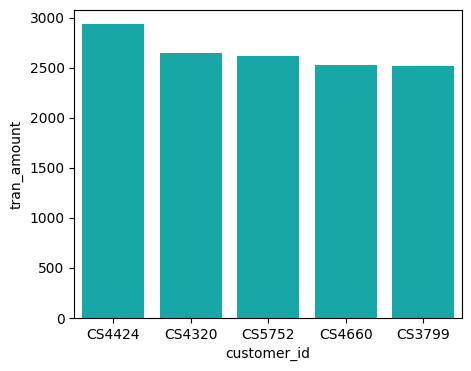

In [18]:
plt.figure(figsize=(5,4))
sns.barplot(x = 'customer_id' , y='tran_amount',data=top_cust_amount,color='c')
plt.show

TIME SERIES ANALYSIS

In [19]:
import matplotlib.dates as mdt

In [20]:
df['month_year'] = df['trans_date'].dt.to_period('M')
df

,customer_id,trans_date,tran_amount,response,month,month_year
0,CS5295,2013-02-11,35,1,2,2013-02
1,CS4768,2015-03-15,39,1,3,2015-03
2,CS2122,2013-02-26,52,0,2,2013-02
3,CS1217,2011-11-16,99,0,11,2011-11
4,CS1850,2013-11-20,78,0,11,2013-11
...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,6,2011-06
124996,CS7232,2014-08-19,38,0,8,2014-08
124997,CS8731,2014-11-28,42,0,11,2014-11
124998,CS8133,2013-12-14,13,0,12,2013-12


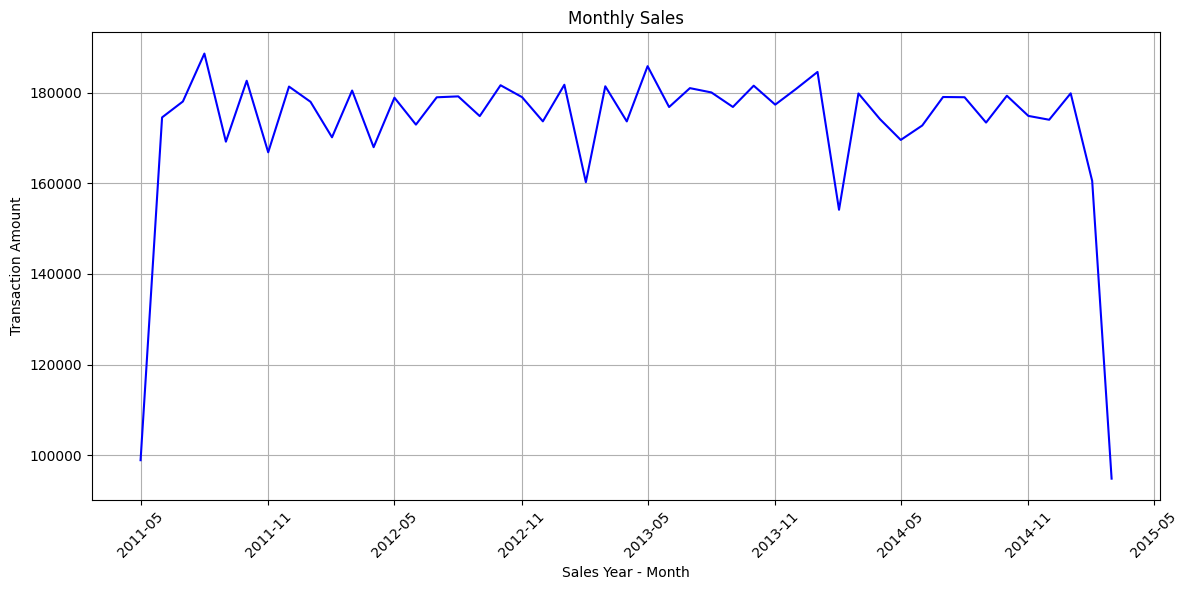

In [21]:
monthly_sales = df.groupby('month_year')['tran_amount'].sum()
plt.figure(figsize=(12,6))

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.plot(monthly_sales.index , monthly_sales.values,color = 'b')

plt.gca().xaxis.set_major_formatter(mdt.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdt.MonthLocator(interval=6))
plt.title('Monthly Sales')
plt.xlabel('Sales Year - Month')
plt.ylabel('Transaction Amount')
plt.xticks(rotation = 45)
plt.grid(True)
plt.tight_layout()
plt.show()


COHORT SAGMENTATION

In [22]:
## Recency
recency = df.groupby('customer_id')['trans_date'].max()

## Freaquency 
frequency = df.groupby('customer_id')['trans_date'].count()
## Monitery 
monitery = df.groupby('customer_id')['tran_amount'].sum()

rfm = pd.DataFrame({"Recency" : recency,
                   "Frequency" : frequency,
                   "Monitery" : monitery})
rfm

,Recency,Frequency,Monitery
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [23]:
## CUSTOMER SAGMENTATION 
def cust_segment (row):
    if (row['Recency'].year >= 2012) & (row['Frequency'] >= 15) & (row['Monitery']>1000):
        return 'P0'
    elif (2011 <= row['Recency'].year <2012) | (10 <= row['Frequency'] <15) & (500 <= row['Monitery'] <= 1000):
        return 'P1'
    else:
        return 'P2'
rfm['Segment'] = rfm.apply(cust_segment , axis=1)
rfm

,Recency,Frequency,Monitery,Segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P1
...,...,...,...,...
CS8996,2014-12-09,13,582,P1
CS8997,2014-06-28,14,543,P1
CS8998,2014-12-22,13,624,P1


In [24]:
rfm['Segment'].value_counts()

Segment
P0    4423
P2    1448
P1    1013
Name: count, dtype: int64

CHURN ANALYSIS

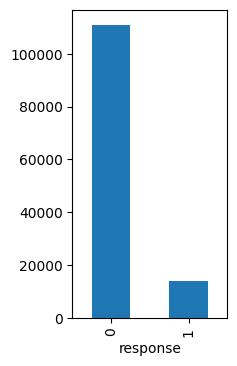

In [25]:
## FIND RESPONCES 
churn_count = df['response'].value_counts()
churn_count

## Visual Understanding 
plt.figure(figsize=(2,4))
churn_count.plot(kind = 'bar')
plt.show()

In [31]:
churn_rate = df['response'].mean()*100
churn_rate

np.float64(11.076346934039643)

ANALYZING TOP CUSTOMERS

In [27]:
top_cus = monitery.sort_values(ascending=False).head(5).index
top_cus_df = df[df['customer_id'].isin(top_cus)]

top_cus_sales = top_cus_df.groupby(['customer_id' , 'month_year'])['tran_amount'].sum().unstack(level=0)



<Figure size 200x400 with 0 Axes>

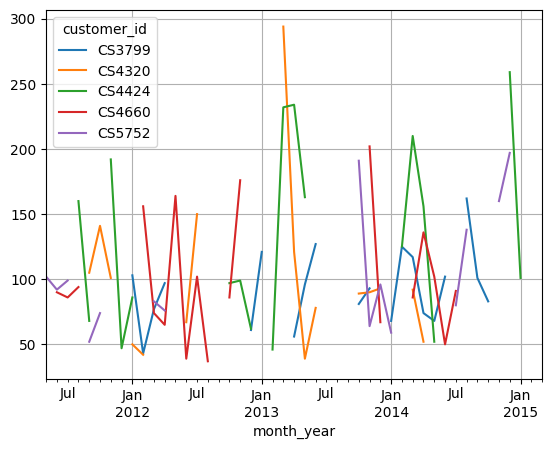

In [28]:
plt.figure(figsize=(2,4))
top_cus_sales.plot(kind = 'line')
plt.grid(True)
plt.show()

In [29]:
df.to_csv('MainData.csv')

In [30]:
rfm.to_csv('Adv_Analysis.csv')